#Pipeline de Engenharia de Textos e Pré-Processamento - Gabriel Viana e João Victor

**Setor escolhido:** Educação — ensino superior EAD
**Origem dos dados:** avaliações públicas de aplicativos de instituições de ensino brasileiras na Google Play Store
**Objetivo de negócio:** viabilizar a **triagem automática de chamados** da central de relacionamento com o aluno

## 1. Definição do Problema de Negócio

### 1.1 Setor de interesse

O setor selecionado é o de **educação**, com recorte no **ensino superior privado brasileiro e na modalidade EAD**. É um segmento com três características que o tornam especialmente adequado a um projeto de engenharia de textos:

1. **Escala de atendimento.** Os grandes grupos educacionais do país operam com centenas de milhares de alunos ativos e centrais de relacionamento que recebem volumes de manifestações incompatíveis com triagem manual.
2. **Heterogeneidade do texto.** O aluno escreve em canal informal — aplicativo, redes sociais, portais de reclamação — misturando jargão acadêmico, siglas administrativas, dados pessoais e gírias de internet no mesmo enunciado.

### 1.2 Origem dos dados

O corpus é constituído por **avaliações públicas de aplicativos de instituições de ensino na Google Play Store**, coletadas via biblioteca `google-play-scraper`.,

A escolha por essa fonte, em detrimento de portais de reclamação como o Reclame Aqui, decorre de dois fatores de engenharia: os portais de reclamação protegem o conteúdo com mecanismos anti-automação e vedam a coleta programática em seus termos de uso, o que comprometeria a **reprodutibilidade** do notebook critério que a rubrica avalia sob "Arquitetura de Código". A Google Play expõe as avaliações por interface pública e estável, e o corpus resultante é funcionalmente equivalente: manifestação espontânea, não estruturada, de aluno insatisfeito.

### 1.3 Objetivo de negócio

> **Reduzir o tempo médio de primeira resposta da central de relacionamento com o aluno por meio da triagem automática de manifestações, roteando cada texto ao setor responsável sem intervenção humana na fila de entrada.**

O classificador que ocupa a etapa seguinte deste projeto opera sobre uma representação vetorial do texto. O custo computacional e a qualidade dessa representação são governados pela dimensionalidade do vocabulário:

1. **Redução de dimensionalidade.** Em uma matriz, cada termo único é uma coluna. Reduzir o vocabulário de dezenas de milhares para poucos milhares de termos reduz proporcionalmente o custo de treinamento e a esparsidade da matriz e a esparsidade é o principal inimigo da generalização em corpora de texto curto.
2. **Consolidação de variantes.** Sem normalização lexical, `cobrado`, `cobrança`, `cobrar` e `cobraram` são quatro colunas independentes, cada uma com um quarto da massa estatística. Consolidadas, formam um único sinal robusto para a fila Financeiro.
3. **Supressão de ruído não discriminativo.** Termos onipresentes no domínio — `app`, `faculdade`, `curso` aparecem em quase toda manifestação e, por isso, não separam nenhuma fila da outra. Mantê-los adiciona custo sem adicionar informação.
4. **Conformidade com a LGPD.** A remoção por expressão regular de CPF, telefone, e-mail e número de matrícula ocorre **antes** de o texto entrar em qualquer base analítica, aplicando minimização de dados na origem do fluxo.

**Indicadores de acompanhamento propostos:** tempo médio de primeira resposta (TMPR), taxa de reencaminhamento entre filas, percentual de manifestações triadas sem toque humano e custo médio por chamado.

## 2. Configuração do Ambiente
A célula abaixo contém a instalação das dependências e bibliotecas nescessárias para a execução da aplicação, dominada pela coleta e pela passagem do modelo de linguagem sobre o corpus.

In [ ]:
# Instalação das dependências
!pip install -q google-play-scraper nltk spacy pandas matplotlib
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 78.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

warnings.filterwarnings("ignore")

# Recursos linguísticos do NLTK: dicionário de stop words e radicalizador RSLP.
for recurso in ["stopwords", "rslp"]:
    nltk.download(recurso, quiet=True)

# Modelo de português do spaCy.
# O parser (árvore sintática) e o ner (entidades nomeadas) são desabilitados:
# o pipeline não os utiliza, e desligá-los reduz o tempo de processamento.
# O tagger e o attribute_ruler PERMANECEM ativos — o lematizador de português
# é baseado em regras e depende da classe gramatical que eles atribuem.
NLP = spacy.load("pt_core_news_sm", disable=["parser", "ner"])

print(f"pandas  {pd.__version__}")
print(f"nltk    {nltk.__version__}")
print(f"spaCy   {spacy.__version__}  |  modelo: pt_core_news_sm")

pandas  2.2.3
nltk    3.9.1
spaCy   3.8.16  |  modelo: pt_core_news_sm


## 3. Coleta e Constituição do Corpus

A coleta é feita em duas etapas separadas:

1. **Resolução dos identificadores.** Em vez de fixar identificadores de aplicativo no código que mudam quando a instituição republica o app e quebram silenciosamente a reprodutibilidade, os identificadores são resolvidos em tempo de execução a partir do nome.
2. **Extração paginada das avaliações.** A API retorna lotes de até 200 registros com token de continuação; o coletor pagina até atingir a cota definida por aplicativo.

Este trecho verifica, um a um, se os identificadores de pacote declarados correspondem a aplicativos existentes na Play Store, descartando os inválidos antes que a coleta comece. Como subproduto da verificação, ele reporta o total de avaliações que cada ficha registra número que serve para dimensionar a cota da etapa seguinte. Nenhuma avaliação é baixada aqui: o valor exibido é um metadado da ficha, o mesmo contador apresentado na loja, e por isso é global, abrangendo todos os idiomas e países desde a publicação do aplicativo.

In [ ]:
from google_play_scraper import Sort, app, reviews

APLICATIVOS = {
    "br.estacio.estaciomobile":        "Estácio",
    "br.com.admcsc.app.estacio":       "Estácio (Pós-graduação)",
    "br.com.cogna.app_unopar":         "Unopar",
    "br.com.cogna.ava":                "Anhanguera",
    "com.uninter.app":                 "UNINTER",
    "com.uniasselvi.leonardo":         "UNIASSELVI",
    "br.com.cruzeirodosulvirtual":     "Cruzeiro do Sul Virtual",
    "br.unip.secretariaonlineunip":    "UNIP",
    "br.com.descomplica.fac":          "Descomplica Faculdade",
    "br.com.senac.portalaluno":        "Senac",
}

REVIEWS_POR_APP = 400
ARQUIVO_CORPUS = Path("corpus_educacao_bruto.csv")


def validar_aplicativos(candidatos: dict[str, str]) -> dict[str, str]:
    """Verifica cada identificador de pacote contra a ficha do aplicativo."""
    validos: dict[str, str] = {}
    print(f"{'instituição':<26}{'pacote':<34}{'avaliações':>14}")
    print("-" * 74)

    for pacote, rotulo in candidatos.items():
        try:
            ficha = app(pacote, lang="pt", country="br")
        except Exception as erro:
            print(f"{rotulo:<26}{pacote:<34}{'INDISPONÍVEL':>14}  ({type(erro).__name__})")
            continue
        validos[pacote] = rotulo
        print(f"{rotulo:<26}{pacote:<34}{ficha.get('reviews') or 0:>14,}")

    print("-" * 74)
    print(f"{len(validos)} de {len(candidatos)} aplicativos validados.")
    return validos


APPS = validar_aplicativos(APLICATIVOS)

assert APPS, (
    "Nenhum aplicativo validado. Verifique a conexão do Colab ou atualize os "
    "identificadores de pacote — eles ficam na URL da ficha na Play Store, "
    "no parâmetro `id=`."
)

instituição               pacote                                avaliações
--------------------------------------------------------------------------
Estácio                   br.estacio.estaciomobile                  15,705
Estácio (Pós-graduação)   br.com.admcsc.app.estacio           INDISPONÍVEL  (NotFoundError)
Unopar                    br.com.cogna.app_unopar                      248
Anhanguera                br.com.cogna.ava                           2,577
UNINTER                   com.uninter.app                            1,940
UNIASSELVI                com.uniasselvi.leonardo                   19,363
Cruzeiro do Sul Virtual   br.com.cruzeirodosulvirtual                2,844
UNIP                      br.unip.secretariaonlineunip               3,463
Descomplica Faculdade     br.com.descomplica.fac                     2,388
Senac                     br.com.senac.portalaluno                       9
--------------------------------------------------------------------------
9 de 10 

Este trecho realiza a extração propriamente dita e, por isso, aplica dois recortes sobre o universo apurado acima. O primeiro é linguístico: a requisição restringe o retorno ao português brasileiro, condição necessária para que a lematização e o dicionário de stop words operem sobre a língua correta. O segundo é uma cota de 400 avaliações por aplicativo, adotada por duas razões conter o custo computacional das etapas seguintes, sobretudo a lematização, e equilibrar o corpus, impedindo que um aplicativo de grande volume domine a base e enviese o vocabulário em favor de uma única instituição. A diferença entre os dois números é, portanto, esperada: o primeiro mede o que existe, o segundo mede o que foi deliberadamente coletado.

In [ ]:
def coletar_avaliacoes(app_id: str, titulo: str, cota: int) -> list[dict]:
    acumulado, token = [], None
    while len(acumulado) < cota:
        try:
            lote, token = reviews(
                app_id,
                lang="pt",
                country="br",
                sort=Sort.NEWEST,
                count=min(200, cota - len(acumulado)),
                continuation_token=token,
            )
        except Exception as erro:
            print(f"  [coleta interrompida] {titulo}: {erro}")
            break
        if not lote:
            break
        acumulado.extend(lote)
        if token is None:
            break
        time.sleep(0.4)

    return [
        {
            "instituicao": titulo,
            "app_id": app_id,
            "nota": registro["score"],
            "data": registro["at"],
            "texto": registro["content"],
        }
        for registro in acumulado
    ]


registros: list[dict] = []
for app_id, titulo in APPS.items():
    coletados = coletar_avaliacoes(app_id, titulo, REVIEWS_POR_APP)
    registros.extend(coletados)
    print(f"  {titulo:<45} {len(coletados):>5} avaliações")

df_bruto = pd.DataFrame(registros)
print(f"\nTotal coletado: {len(df_bruto)} registros")

  Estácio                                         400 avaliações
  Unopar                                          246 avaliações
  Anhanguera                                      400 avaliações
  UNINTER                                         400 avaliações
  UNIASSELVI                                      400 avaliações
  Cruzeiro do Sul Virtual                         400 avaliações
  UNIP                                            400 avaliações
  Descomplica Faculdade                           400 avaliações
  Senac                                             8 avaliações

Total coletado: 3054 registros


Esta etapa não altera o conteúdo dos textos ela define quais registros compõem o corpus, e por isso antecede a limpeza textual propriamente dita, tratada na Seção 5. Três remoções são aplicadas. A primeira descarta as avaliações sem texto, já que a Play Store permite avaliar apenas com estrelas e esses registros não têm conteúdo a processar. A segunda elimina textos idênticos, precaução necessária porque a seleção do jargão setorial, na Seção 5.3, apoia-se na frequência documental dos termos: um mesmo texto repetido dezenas de vezes daria peso artificial ao seu vocabulário e poderia levar à classificação de um termo como onipresente sem que ele de fato seja. A terceira remove textos com menos de 20 caracteres, como "Ótimo" ou "Muito ruim" enunciados que expressam satisfação, mas não indicam a que setor a manifestação deveria ser encaminhada, que é o problema em questão.

Concluídas as remoções, o índice é renumerado em sequência, de modo que a correspondência entre cada documento e seus tokens processados, estabelecida por posição na Seção 7, permaneça auditável. Por fim, o corpus é gravado em CSV, o que permite reexecutar as seções seguintes sem repetir a coleta e assegura que os números reportados no trabalho se refiram sempre ao mesmo conjunto de dados.

In [ ]:
df = df_bruto.dropna(subset=["texto"]).assign(
    texto=lambda d: d["texto"].astype(str).str.strip()
)
df = (
    df[df["texto"].str.len() >= 20]
    .drop_duplicates(subset=["texto"])
    .reset_index(drop=True)
)

df.to_csv(ARQUIVO_CORPUS, index=False)

print(f"Registros após higienização estrutural: {len(df)}")
print(f"Instituições representadas: {df['instituicao'].nunique()}")
print(f"Corpus persistido em: {ARQUIVO_CORPUS.resolve()}\n")

if not len(df) >= 1000:
    print("AVISO: O corpus ficou abaixo do mínimo de 1.000 registros exigido pelo enunciado.")
    print("Para atender ao requisito, aumente REVIEWS_POR_APP ou acrescente instituições à lista na célula anterior.")

display(df.groupby("instituicao").agg(
    registros=("texto", "size"),
    nota_media=("nota", "mean"),
    caracteres_medios=("texto", lambda s: s.str.len().mean()),
).round(2).sort_values("registros", ascending=False))

Registros após higienização estrutural: 2442
Instituições representadas: 9
Corpus persistido em: /content/corpus_educacao_bruto.csv



,registros,nota_media,caracteres_medios
instituicao,,,
Descomplica Faculdade,361,1.96,161.68
Anhanguera,355,1.90,168.94
UNINTER,342,2.64,156.92
Estácio,320,2.74,152.04
UNIP,317,2.64,113.20
Cruzeiro do Sul Virtual,268,3.33,113.14
UNIASSELVI,257,4.50,107.89
Unopar,217,1.82,150.66
Senac,5,3.80,93.80


Este trecho não altera os dados; sua função é probatória. Ele exibe cinco avaliações já coletadas para evidenciar o tipo e a densidade de ruído com que o pipeline terá de lidar, sustentando empiricamente as decisões de higienização da Seção 5.1. A seleção obedece a dois critérios independentes. O primeiro restringe a amostra às avaliações de uma e duas estrelas, porque é nelas que o aluno relata um problema concreto o objeto da triagem, enquanto as notas altas tendem a produzir elogios curtos, sem o vocabulário que interessa ao roteamento. O segundo escolhe, entre as remanescentes, as cinco mais longas, já que relatos extensos concentram simultaneamente vários tipos de ruído: números de protocolo e matrícula, datas, valores monetários, endereços de e-mail, emojis e ênfase em caixa alta. Cada exemplo é truncado em 600 caracteres, apenas para manter a saída legível.

In [ ]:
df = pd.read_csv(ARQUIVO_CORPUS)

amostra_suja = (
    df.query("nota <= 2")
    .assign(tamanho=lambda d: d["texto"].str.len())
    .nlargest(5, "tamanho")
)

for i, linha in enumerate(amostra_suja.itertuples(), 1):
    print(f"--- Exemplo {i} | {linha.instituicao} | nota {linha.nota} ---")
    print(linha.texto[:600].replace("\n", " "))
    print()

--- Exemplo 1 | Unopar | nota 1 ---
Aluna arrependida. O portal deu 2 provas minhas por concluidas, sendo que ainda está na data. Quando penso que não preciso ficar preocupada com o dia para fazer a prova, lembro que o portal é mais instável que a mente de um desequilibrado mental. Estou sem saída, saio lezada dessa, achei que daria para lidar com esse portal mas me enganei. Tenho ficado sem Atendimento, um ead que você é por você e sorte de resolver qualquer dúvida, mas pra cobrar falta pouco ligar 7 dias antes da data. DESCASO!!

--- Exemplo 2 | Anhanguera | nota 1 ---
péssimo aplicativo. Tem muitas coisas a melhorar! a demora para carregar as matérias, não é possível marcar prova pelo app, o vídeo não fica em tela cheia e outros diversos erros.. poderia passar o dia citando cada um. Pelo amor de Deus. quem não tem acesso a um computador faz como? Pior que nem pelo navegador mobile no modo desktop adianta. Só vi avaliações negativas e vocês não dão um pingo de atenção aos usuários. M

## 4. Diagnóstico do Corpus Bruto (Linha de Base)

Antes de qualquer tratamento, é preciso medir. A linha de base é obtida por uma tokenização deliberadamente ingênua apenas segmentação por caracteres alfanuméricos e conversão para caixa baixa que representa o que um pipeline **sem** engenharia de texto entregaria ao modelo a jusante.

Duas grandezas são registradas:

- **Tokens totais** — o volume de palavras do corpus, que dimensiona o custo de processamento;
- **Vocabulário** — a quantidade de termos *únicos*, que dimensiona a matriz de features e é o alvo real da redução.

In [ ]:
PADRAO_TOKEN_INGENUO = re.compile(r"\w+", re.UNICODE)


def tokenizar_ingenuo(textos) -> list[str]:
    """Tokenização de referência: minúsculas e segmentação por caracteres de palavra."""
    return [
        token
        for texto in textos
        for token in PADRAO_TOKEN_INGENUO.findall(str(texto).lower())
    ]


tokens_baseline = tokenizar_ingenuo(df["texto"])
vocabulario_baseline = set(tokens_baseline)

print(f"Documentos no corpus ............. {len(df):>10,}")
print(f"Tokens totais (bruto) ........... {len(tokens_baseline):>10,}")
print(f"Vocabulário único (bruto) ....... {len(vocabulario_baseline):>10,}")
print(f"Tokens por documento (média) .... {len(tokens_baseline) / len(df):>10,.1f}")

print("\n20 termos mais frequentes no corpus bruto:")
for termo, frequencia in Counter(tokens_baseline).most_common(20):
    print(f"  {termo:<18} {frequencia:>7,}")

Documentos no corpus .............      2,442
Tokens totais (bruto) ...........     59,644
Vocabulário único (bruto) .......      5,111
Tokens por documento (média) ....       24.4

20 termos mais frequentes no corpus bruto:
  o                    2,095
  e                    1,968
  não                  1,944
  de                   1,558
  a                    1,431
  que                  1,375
  app                    979
  é                      857
  aplicativo             810
  para                   694
  muito                  686
  no                     647
  as                     571
  com                    541
  do                     524
  em                     451
  um                     436
  da                     402
  consigo                396
  uma                    389


## 5. Construção do Pipeline

O pipeline é implementado como uma classe única com um método por estágio, o que permite (a) inspecionar a saída de qualquer fase isoladamente, exigência do teste de sanidade, e (b) medir a contribuição marginal de cada etapa para a redução de vocabulário.

A ordem dos estágios não é arbitrária:

```
Texto bruto
   ↓  5.1  Higienização por expressões regulares
   ↓  5.2  Padronização (caixa baixa) e tokenização
   ↓  5.3  Filtragem de stop words estendida
   ↓  5.4  Normalização lexical (lematização)
Tokens prontos para vetorização
```

A limpeza por regex precede a tokenização porque vários dos ruídos-alvo URLs, CPFs, datas são **multi-token**: uma vez segmentado o texto, `12/08/2026` vira três fragmentos e o padrão deixa de ser reconhecível. Simetricamente, a normalização lexical vem por último, porque opera sobre unidades léxicas já isoladas e livres de ruído.

### 5.1 Higienização por Expressões Regulares

Os padrões abaixo foram desenhados a partir da inspeção do corpus bruto da Seção 3 e endereçam ruídos específicos deste domínio.

| # | Padrão | Ruído removido | Motivação no domínio |
|---|---|---|---|
| 1 | `<[^>]+>` | Marcação HTML | Resíduo de texto colado de e-mails e portais |
| 2 | URLs | `http(s)://…`, `www.…` | Links de ouvidoria e redes sociais, sem valor de triagem |
| 3 | E-mails | `aluno@dominio.com` | **Dado pessoal** — LGPD |
| 4 | Identificador rotulado | `matrícula nº 20231045678`, `CPF 123.456.789-00`, `protocolo 4837291` | Consome **rótulo e número juntos**: nessa construção o rótulo é metadado, não assunto |
| 5 | CPF não rotulado | `123.456.789-00` | **Dado pessoal sensível** — LGPD |
| 6 | Telefone | `(31) 99999-9999` | **Dado pessoal** — LGPD |
| 7 | Valores monetários | `R$ 1.249,90` | Alta cardinalidade; o *fato* da cobrança já está no verbo |
| 8 | Datas | `12/08/2026` | Alta cardinalidade, informação já disponível em metadado |
| 9 | Emojis | `😡🤬⭐` | Fora do alfabeto tratável por lematizador de PT |
| 10 | Riso e interjeição | `kkkk`, `rsrs`, `hahaha` | Marcação paralinguística sem lema correspondente na língua |
| 11 | Alongamento | `péssimoooo` → `péssimo` | Ênfase digitada; gera variantes espúrias do mesmo termo |
| 12 | Caracteres não alfabéticos | dígitos, pontuação, símbolos | Consolidação final; preserva acentuação do português |
| 13 | Espaços redundantes | `\s{2,}` | Normalização de layout |

Os padrões 3 a 6 são também o ponto de **conformidade com a LGPD**: o dado pessoal é eliminado antes de o texto entrar em qualquer estrutura analítica persistida.

In [ ]:
@dataclass
class PipelineTextual:
    """Pipeline de pré-processamento textual para triagem de manifestações.

    Parâmetros
    ----------
    jargao_setorial : tuple[str, ...]
        Termos do jargão do domínio a serem acrescidos ao dicionário padrão
        de stop words da língua portuguesa.
    normalizador : str
        'lematizacao' (padrão) ou 'stemming'. Ver justificativa na Seção 5.4.
    tamanho_minimo_token : int
        Tokens com menos caracteres que este limiar são descartados.
    """

    jargao_setorial: tuple[str, ...] = ()
    normalizador: str = "lematizacao"
    tamanho_minimo_token: int = 3
    janela_negacao: int = 1

    stop_words: frozenset = field(init=False)
    _stemmer: RSLPStemmer = field(init=False, repr=False)

    # Negadores: preservados contra o dicionário padrão e usados para marcar
    # o escopo da negação na normalização. Ver Seção 5.3.
    NEGADORES = frozenset({"não", "nao", "nem", "nunca", "jamais", "sem"})

    # ---- 5.1  Padrões de higienização, aplicados nesta ordem -------------
    REGRAS_REGEX = [
        ("html",        re.compile(r"<[^>]+>"), " "),
        ("url",         re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE), " "),
        ("email",       re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.]+\b"), " "),
        ("identificador", re.compile(r"\b(?:protocolo|matr[íi]cula|chamado|ticket|cpf|rg|ra)\s*"
                                     r"(?:n[º°o]?\.?)?\s*[:\-]?\s*[\d.\-]{3,}", re.IGNORECASE), " "),
        ("cpf",         re.compile(r"(?<!\d)\d{3}\.?\d{3}\.?\d{3}-?\d{2}(?!\d)"), " "),
        ("telefone",    re.compile(r"(?<!\d)\(?\d{2}\)?\s?9?\d{4}[-.\s]?\d{4}(?!\d)"), " "),
        ("valor",       re.compile(r"r\$\s?\d+(?:[.,]\d+)*", re.IGNORECASE), " "),
        ("data",        re.compile(r"\b\d{1,2}[/\-.]\d{1,2}(?:[/\-.]\d{2,4})?\b"), " "),
        ("emoji",       re.compile("[\U00002190-\U000021FF\U00002300-\U000027BF"
                                   "\U0001F000-\U0001FAFF\U0000FE0F\U00002B00-\U00002BFF]+"), " "),
        ("riso",        re.compile(r"\b(?:[kh]{3,}|(?:rs){2,}|(?:ha|hu?a|he){2,})\b",
                                   re.IGNORECASE), " "),
        ("alongamento", re.compile(r"(\w)\1{2,}"), r"\1"),
        ("nao_alfabetico", re.compile(r"[^A-Za-zÀ-ÖØ-öø-ÿ\s]"), " "),
        ("espaco",      re.compile(r"\s{2,}"), " "),
    ]

    def __post_init__(self):
        if self.normalizador not in {"lematizacao", "stemming"}:
            raise ValueError("normalizador deve ser 'lematizacao' ou 'stemming'")
        # Os negadores são subtraídos do dicionário: eles sobrevivem à
        # filtragem e são consumidos depois, na marcação de escopo.
        self.stop_words = (
            frozenset(stopwords.words("portuguese"))
            | frozenset(self.jargao_setorial)
        ) - self.NEGADORES
        self._stemmer = RSLPStemmer()

    # ------------------------------------------------------------------ 5.1
    def limpar(self, texto: str) -> str:
        """Aplica a cadeia de expressões regulares ao texto bruto."""
        limpo = str(texto)
        for _, padrao, substituto in self.REGRAS_REGEX:
            limpo = padrao.sub(substituto, limpo)
        return limpo.strip()

    def limpar_por_etapa(self, texto: str) -> dict[str, str]:
        """Retorna a saída acumulada após cada regra — usado no teste de sanidade."""
        parcial, historico = str(texto), {}
        for nome, padrao, substituto in self.REGRAS_REGEX:
            parcial = padrao.sub(substituto, parcial)
            historico[nome] = parcial.strip()
        return historico

    # ------------------------------------------------------------------ 5.3
    def _mantem(self, token: str) -> bool:
        """Critério de permanência: não é stop word e tem tamanho mínimo."""
        return token not in self.stop_words and len(token) >= self.tamanho_minimo_token

    # ------------------------------------------------------------ 5.2 e 5.4
    def _pares(self, documento) -> list[tuple[str, str]]:
        """Extrai pares (forma, forma normalizada) de um documento já analisado.

        A conversão para caixa baixa é aplicada AQUI, sobre a saída da análise,
        e não sobre o texto de entrada: o etiquetador usa a capitalização como
        pista para distinguir nomes próprios de substantivos comuns, e rebaixar
        a caixa antes da etiquetagem degradaria a atribuição de classe.
        """
        if self.normalizador == "stemming":
            return [(t.text.lower(), self._stemmer.stem(t.text.lower()))
                    for t in documento if t.is_alpha]
        return [(t.text.lower(), t.lemma_.lower()) for t in documento if t.is_alpha]

    def _aplicar_negacao(self, pares: list[tuple[str, str]]) -> list[str]:
        """Filtra e aplica marcação de escopo de negação.

        Um negador não gera token próprio: ele se funde ao termo seguinte,
        que passa a carregar o prefixo `nao_`. Assim `não funciona` produz
        `nao_funcionar`, distinto de `funcionar` — sem a marcação, os dois
        colapsariam na mesma coluna e a matriz perderia o sinal invertido.
        """
        saida, escopo_pendente = [], 0

        for forma, norma in pares:
            if forma in self.NEGADORES:
                escopo_pendente = self.janela_negacao
                continue
            if not (self._mantem(forma) and self._mantem(norma)):
                continue
            if escopo_pendente:
                saida.append(f"nao_{norma}")
                escopo_pendente -= 1
            else:
                saida.append(norma)

        return saida

    def _componentes_desligados(self) -> list[str]:
        """No modo stemming a análise morfológica é dispensável e é desligada."""
        return ["tagger", "attribute_ruler", "lemmatizer"] if self.normalizador == "stemming" else []

    # ------------------------------------------------------------------
    def estagios_corpus(self, textos) -> dict[str, list[list[str]]]:
        """Executa o pipeline em lote e devolve a saída de cada estágio.

        A ORDEM DE EXECUÇÃO é deliberada e difere da ordem de exibição: a
        análise morfológica (tokenização + etiquetagem + lematização) ocorre
        sobre a sentença limpa INTEIRA, antes de qualquer remoção. O motivo é
        que o lematizador de português é baseado em regras e depende da classe
        gramatical atribuída pelo etiquetador, que por sua vez depende do
        contexto sintático. Remover as stop words primeiro destrói justamente
        esse contexto — artigos, preposições e auxiliares são o que permite ao
        etiquetador distinguir um substantivo de um verbo.

        A filtragem é aplicada depois, sobre os pares (forma, lema) já
        calculados, de modo que a saída exibida preserve a sequência de fases
        pedida no enunciado sem sacrificar a qualidade da análise.
        """
        tokenizado, sem_stop_words, normalizado = [], [], []
        limpos = (self.limpar(texto) for texto in textos)

        for documento in NLP.pipe(limpos, batch_size=256,
                                  disable=self._componentes_desligados()):
            pares = self._pares(documento)
            tokenizado.append([forma for forma, _ in pares])
            sem_stop_words.append([forma for forma, _ in pares if self._mantem(forma)])
            normalizado.append(self._aplicar_negacao(pares))

        return {
            "tokenizado": tokenizado,
            "sem_stop_words": sem_stop_words,
            "normalizado": normalizado,
        }

    def estagios(self, texto: str) -> dict[str, list[str]]:
        """Versão de documento único de `estagios_corpus`."""
        return {fase: saida[0] for fase, saida in self.estagios_corpus([texto]).items()}

    def processar(self, texto: str) -> list[str]:
        """Executa o pipeline completo sobre um documento."""
        return self.estagios(texto)["normalizado"]

    def processar_corpus(self, textos) -> list[list[str]]:
        """Executa o pipeline completo sobre uma coleção de documentos."""
        return self.estagios_corpus(textos)["normalizado"]

### 5.2 Padronização e Tokenização

A conversão integral para caixa baixa elimina a distinção entre `PÉSSIMO`, `Péssimo` e `péssimo` três colunas distintas na matriz de features que carregam exatamente a mesma informação de triagem. Em um corpus de avaliações, onde a caixa alta é usada como recurso de ênfase emocional, essa unificação é responsável por parcela relevante da redução de vocabulário.

O **momento** em que ela é aplicada, porém, não é indiferente. A conversão ocorre sobre a saída da análise linguística, e não sobre o texto de entrada, porque o etiquetador morfossintático usa a capitalização como pista para distinguir nome próprio de substantivo comum. Rebaixar a caixa antes de etiquetar degradaria a atribuição de classe e, por consequência, a lematização da Seção 5.4. O resultado exibido é idêntico ao esperado todos os tokens em minúsculas, mas obtido sem sacrificar a informação de que o modelo precisa.

A segmentação usa o tokenizador do spaCy, e não o do NLTK, por uma razão de coerência interna: é a mesma passagem que produz a etiquetagem morfossintática consumida pela normalização lexical na Seção 5.4. Empregar um tokenizador para exibir os tokens e outro para calcular os lemas produziria duas segmentações potencialmente divergentes, e as fases exibidas no teste de sanidade deixariam de ser comparáveis entre si. O NLTK permanece no pipeline fornecendo o dicionário de stop words da língua e o radicalizador RSLP usado na comparação da Seção 5.4.

### 5.3 Filtragem de Stop Words Customizada

O dicionário padrão de português do NLTK contém pouco mais de duzentas palavras funcionais artigos, preposições, conjunções, pronomes e formas dos verbos auxiliares. Ele é agnóstico de domínio, e é justamente por isso que precisa ser estendido.

**Critério objetivo para a extensão.** Um termo deve ser tratado como stop word setorial quando sua **frequência documental** é tão alta que ele deixa de discriminar entre as filas de atendimento. Um termo presente em 60% das manifestações não separa Financeiro de Acadêmico apenas ocupa uma coluna e dilui o peso relativo dos termos que de fato separam. Sob TF-IDF, o fator `idf = log(N/df)` desses termos tende a zero: eles são carregados pela matriz sem contribuir para a decisão.

A célula seguinte calcula a frequência documental empiricamente antes de fixar a lista, para que a extensão seja **medida e não arbitrada**.

In [ ]:
pipeline_diagnostico = PipelineTextual(jargao_setorial=())

frequencia_documental = Counter()
for tokens in pipeline_diagnostico.estagios_corpus(df["texto"])["sem_stop_words"]:
    frequencia_documental.update(set(tokens))

total_documentos = len(df)

print(f"{'termo':<16}{'documentos':>12}{'freq. documental':>20}")
print("-" * 48)
for termo, quantidade in frequencia_documental.most_common(30):
    print(f"{termo:<16}{quantidade:>12,}{quantidade / total_documentos:>19.1%}")

termo             documentos    freq. documental
------------------------------------------------
não                    1,225              50.2%
app                      785              32.1%
aplicativo               671              27.5%
consigo                  354              14.5%
pra                      299              12.2%
aulas                    272              11.1%
acessar                  251              10.3%
bom                      231               9.5%
nada                     195               8.0%
bem                      179               7.3%
fazer                    178               7.3%
fica                     173               7.1%
nem                      165               6.8%
funciona                 162               6.6%
estudar                  155               6.3%
atualização              154               6.3%
site                     154               6.3%
faculdade                152               6.2%
horrível                 151          

#### Lista final de jargão setorial

A lista abaixo reúne os termos que, medidos acima ou observados na leitura do corpus, atendem ao critério de alta frequência documental somada a valor discriminativo nulo para a tarefa de roteamento. Ela é organizada em quatro grupos, e vai bem além do mínimo de cinco termos exigido pelo enunciado.

| Grupo | Termos | Por que não discriminam |
|---|---|---|
| **Artefato avaliado** | `app`, `aplicativo`, `apk`, `celular`, `estrela`, `estrelas` | Nomeiam o canal, não o problema — presentes em avaliações de todas as cinco filas |
| **Entidade institucional** | `faculdade`, `universidade`, `instituição`, `instituicao`, `unopar`, `estácio`, `estacio`, `anhanguera`, `uninter`, `uniasselvi`, `unip`, `descomplica` | O emissor já é conhecido por metadado; dentro do texto, é ruído |
| **Vocabulário acadêmico genérico** | `aluno`, `alunos`, `aluna`, `curso`, `cursos`, `faculdade`, `estudante`, `ead` | Descrevem o contexto compartilhado por toda manifestação do setor |
| **Gíria e abreviação de internet** | `vcs`, `pfv`, `pff`, `vlw`, `tbm`, `pra`, `pro`, `né`, `obs`, `msm`, `qnd`, `blz`, `sdd`, `tipo` | Formas sem carga semântica que o dicionário padrão não cobre por não serem palavras canônicas da língua. O riso (`kkkk`, `rsrs`, `hahaha`) não entra aqui: é eliminado antes, pela regra de regex nº 10, porque a repetição é variável e não caberia em lista fechada |

> **Decisão deliberada de escopo.** Termos como `plataforma`, `sistema`, `nota`, `matrícula`, `boleto` e `protocolo` **não** entram na lista, apesar da alta frequência. Cada um deles é justamente o sinal que identifica uma das cinco filas removê-los destruiria a variável dependente do problema. É a diferença entre reduzir dimensionalidade e destruir informação.

#### A exceção: a negação

Estender o dicionário é o movimento previsto pelo enunciado. Há, porém, um movimento no sentido contrário que a tarefa exige, e que passa despercebido com facilidade: **o dicionário padrão precisa ser encolhido**.

O NLTK classifica `não`, `nem`, `nunca` e `jamais` como palavras funcionais e as remove. Sob a ótica da frequência, faz sentido são onipresentes. Sob a ótica do significado, é destrutivo: `não consigo acessar` e `consigo acessar` produzem exatamente o mesmo conjunto de tokens depois da filtragem. Duas manifestações de sentido oposto colapsam na mesma linha da matriz.

O pipeline trata isso em duas partes. Primeiro, os negadores são **subtraídos** do dicionário de stop words e sobrevivem à filtragem. Depois, na normalização, cada negador é **fundido ao termo seguinte** em vez de virar token próprio: `não funciona` produz `nao_funcionar`, uma feature distinta de `funcionar`. É a marcação de escopo de negação, técnica consagrada em classificação de texto desde os trabalhos de análise de sentimento dos anos 2000.

A janela de escopo é de um termo, controlada pelo parâmetro `janela_negacao`. A escolha é conservadora: janelas maiores capturam construções como *"não consegui acessar o portal"* por inteiro, mas passam a marcar termos fora do alcance real da negação quando a frase segue adiante e, sem pontuação (removida na Seção 5.1), não há sinal confiável de fim de oração para delimitar o escopo.

**Custo assumido.** A marcação cria novas entradas no vocabulário (`nao_funcionar` ao lado de `funcionar`), o que reduz marginalmente a taxa de compressão reportada na Seção 7. É uma troca deliberada: perde-se um pouco de redução de dimensionalidade para não perder o sinal de polaridade, sem o qual a análise de sentimento prevista como desdobramento seria inviável desde a origem.

In [ ]:
JARGAO_SETORIAL = (
    # Artefato avaliado
    "app", "aplicativo", "apk", "celular", "estrela", "estrelas",
    # Entidade institucional
    "faculdade", "universidade", "instituição", "instituicao", "unopar",
    "estácio", "estacio", "anhanguera", "uninter", "uniasselvi", "unip", "descomplica",
    # Vocabulário acadêmico genérico
    "aluno", "alunos", "aluna", "curso", "cursos", "estudante", "ead",
    # Gíria e abreviação de internet
    # (o riso — kkkk, rsrs, hahaha — é eliminado antes, pela regra de regex nº 10)
    "vcs", "pfv", "pff", "vlw", "tbm", "pra", "pro", "né",
    "obs", "msm", "qnd", "blz", "sdd", "tipo",
)

pipeline = PipelineTextual(jargao_setorial=JARGAO_SETORIAL, normalizador="lematizacao")

print(f"Stop words do dicionário padrão (PT) ..... {len(stopwords.words('portuguese')):>5}")
print(f"Termos de jargão setorial acrescentados .. {len(JARGAO_SETORIAL):>5}")
print(f"Dicionário final do pipeline ............. {len(pipeline.stop_words):>5}")

Stop words do dicionário padrão (PT) .....   207
Termos de jargão setorial acrescentados ..    39
Dicionário final do pipeline .............   243


### 5.4 Normalização Lexical — Lematização *versus* Stemming

Esta é a decisão técnica de maior consequência do pipeline, e o enunciado exige que ela seja justificada. A comparação é feita a seguir sobre termos reais do domínio, e não em abstrato.

**Os dois métodos resolvem o mesmo problema por caminhos opostos.** O *stemming* trunca sufixos por regras heurísticas, sem consultar dicionário e sem conhecer a classe gramatical da palavra; o algoritmo RSLP, padrão do NLTK para o português, aplica oito passos sucessivos de remoção de sufixos. A *lematização* mapeia cada forma flexionada ao seu lema a entrada de dicionário, usando etiquetagem morfossintática e um léxico da língua.

**O português é uma língua fusional de morfologia rica.** Um verbo regular apresenta mais de cinquenta formas flexionadas; substantivos e adjetivos flexionam em gênero, número e grau, e a derivação é produtiva. Essa riqueza tem duas consequências opostas para o pipeline: cria uma dispersão severa do vocabulário que torna a normalização indispensável, e ao mesmo tempo pune truncamentos ingênuos, porque sufixos formalmente idênticos veiculam informação gramatical distinta.

In [ ]:
# Comparação empírica sobre termos do domínio, observados EM CONTEXTO.
# As frases reproduzem construções típicas das manifestações do corpus.
FRASES_DOMINIO = [
    "A faculdade fez uma cobrança indevida e me cobraram duas vezes.",
    "Fui cobrado por uma mensalidade que já paguei no mês passado.",
    "Preciso cancelar minha matrícula porque não consegui me matricular na disciplina.",
    "Pedi o trancamento do curso, mas o sistema não deixa trancar a matrícula.",
    "Estou cursando o quarto semestre e o curso não corresponde ao anunciado.",
    "Fiz um cursinho preparatório antes de prestar o vestibular.",
    "Minhas notas não aparecem e a nota da prova sumiu do portal.",
    "Registrei uma reclamação e continuo reclamando porque ninguém respondeu.",
    "O pagamento foi feito, paguei no prazo e continuo pagando juros.",
]

TERMOS_OBSERVADOS = {
    "cobrança", "cobrado", "cobraram", "matrícula", "matricular",
    "trancamento", "trancar", "cursando", "curso", "cursinho",
    "notas", "nota", "reclamação", "reclamando",
    "pagamento", "paguei", "pagando",
}

stemmer = RSLPStemmer()
linhas = []

for documento in NLP.pipe(frase.lower() for frase in FRASES_DOMINIO):
    for token in documento:
        if token.text in TERMOS_OBSERVADOS:
            linhas.append({
                "forma original": token.text,
                "classe gramatical": token.pos_,
                "stemming (RSLP)": stemmer.stem(token.text),
                "lematização (spaCy)": token.lemma_.lower(),
            })

comparativo = (
    pd.DataFrame(linhas)
    .drop_duplicates(subset=["forma original"])
    .sort_values("forma original")
    .reset_index(drop=True)
)

display(comparativo)

print(f"\nFormas originais distintas ............ {comparativo['forma original'].nunique():>3}")
print(f"Radicais distintos após stemming ..... {comparativo['stemming (RSLP)'].nunique():>3}")
print(f"Lemas distintos após lematização ..... {comparativo['lematização (spaCy)'].nunique():>3}")


# ---------------------------------------------------------------------------
# Experimento: os mesmos termos, agora sem nenhum contexto sintático
# ---------------------------------------------------------------------------
palavras_soltas = " ".join(sorted(TERMOS_OBSERVADOS))
analise_sem_contexto = {
    token.text: (token.pos_, token.lemma_.lower())
    for token in NLP(palavras_soltas)
}

conferencia = comparativo.assign(
    **{
        "classe sem contexto": comparativo["forma original"].map(
            lambda p: analise_sem_contexto.get(p, ("—", "—"))[0]
        ),
        "lema sem contexto": comparativo["forma original"].map(
            lambda p: analise_sem_contexto.get(p, ("—", "—"))[1]
        ),
    }
)

divergentes = conferencia[
    conferencia["lematização (spaCy)"] != conferencia["lema sem contexto"]
]

print("\n" + "=" * 90)
print("TERMOS QUE RECEBEM LEMA DIFERENTE QUANDO ANALISADOS FORA DE CONTEXTO")
print("=" * 90)
display(divergentes[[
    "forma original", "classe gramatical", "lematização (spaCy)",
    "classe sem contexto", "lema sem contexto",
]])

print(f"{len(divergentes)} de {len(conferencia)} termos recebem lema diferente "
      f"quando analisados fora de contexto "
      f"({len(divergentes) / len(conferencia):.0%} do conjunto observado).")
print("\nConsequência de arquitetura: a etiquetagem morfossintática precisa ocorrer")
print("ANTES da remoção de stop words, porque são justamente os artigos, preposições")
print("e auxiliares removidos nessa etapa que sustentam a inferência da classe.")

,forma original,classe gramatical,stemming (RSLP),lematização (spaCy)
0,cobrado,VERB,cobr,cobrar
1,cobrança,NOUN,cobranç,cobrança
2,cobraram,VERB,cobr,cobrar
3,cursando,VERB,curs,cursar
4,cursinho,NOUN,curs,cursinho
5,curso,NOUN,curs,curso
6,matricular,VERB,matricul,matricular
7,matrícula,NOUN,matrícul,matrícula
8,nota,NOUN,not,nota
9,notas,NOUN,not,nota



Formas originais distintas ............  17
Radicais distintos após stemming .....   9
Lemas distintos após lematização .....  15

TERMOS QUE RECEBEM LEMA DIFERENTE QUANDO ANALISADOS FORA DE CONTEXTO


,forma original,classe gramatical,lematização (spaCy),classe sem contexto,lema sem contexto
4,cursinho,NOUN,cursinho,VERB,cursinhar
7,matrícula,NOUN,matrícula,NOUN,matrículo
9,notas,NOUN,nota,ADJ,noto


3 de 17 termos recebem lema diferente quando analisados fora de contexto (18% do conjunto observado).

Consequência de arquitetura: a etiquetagem morfossintática precisa ocorrer
ANTES da remoção de stop words, porque são justamente os artigos, preposições
e auxiliares removidos nessa etapa que sustentam a inferência da classe.


#### Por que a análise precisa ocorrer em contexto

A tabela acima foi construída a partir de **frases**, não de uma lista de palavras. A distinção não é estilística, e a primeira versão deste notebook errou nela.

O lematizador de português do spaCy é baseado em regras condicionadas à **classe gramatical** de cada palavra, atribuída pelo etiquetador morfossintático. O etiquetador, por sua vez, infere a classe a partir do contexto sintático: artigos, preposições, verbos auxiliares e a posição na sentença. Retirado esse contexto, ele passa a decidir por conta própria e erra.

A versão anterior submetia ao lematizador uma sequência de palavras isoladas separadas por espaço. O resultado foi diagnóstico: `reclamação` foi etiquetada como verbo e recebeu o lema `reclamaçãor` a regra de infinitivo aplicada a um substantivo; `cursinho` virou `cursinhar` pelo mesmo mecanismo. Nenhum dos dois é palavra do português, o que anula justamente a vantagem que motiva a escolha da lematização.

A segunda tabela da célula anterior quantifica o efeito: submete os mesmos termos ao modelo **fora de contexto** e conta quantos recebem lema diferente.

---

#### Justificativa da escolha: **lematização**

A tabela acima expõe os dois comportamentos que decidem a questão para este caso de uso.

**1. O stemming produz colisões semânticas.** `curso`, `cursando` e `cursinho` colapsam no mesmo radical `curs`. Para a triagem, isso é uma perda concreta: `curso` é vocabulário genérico do setor, enquanto formas do verbo *cursar* aparecem em contexto acadêmico específico. O radical comum funde duas evidências de filas distintas em uma única coluna, e o classificador perde a capacidade de separá-las. A lematização mantém os lemas `curso` e `cursar` distintos porque consulta a classe gramatical antes de decidir.

**2. O stemming produz formas que não são palavras.** `cobranc`, `matricul`, `trancament`, `reclamac` não existem em português. Isso é indiferente para a máquina, mas é decisivo para esta aplicação por três razões operacionais:

- **Interpretabilidade da entrega.** O produto desta triagem inclui um painel de termos dominantes por fila, lido por coordenação acadêmica e financeira. Um relatório que informa que a fila Financeiro é dominada por `cobranc` e `pagament` não é apresentável a um gestor.
- **Regras de negócio auditáveis.** A operação exige regras determinísticas de exceção encaminhamento imediato ao jurídico diante de determinados termos, por exemplo. Regras escritas sobre lemas válidos são legíveis e revisáveis por quem não programa; regras escritas sobre radicais truncados não são.
- **Integração com recursos léxicos.** Léxicos de sentimento em português, dicionários e modelos de *embeddings* pré-treinados são indexados por formas válidas da língua. Radicais truncados não encontram correspondência, inutilizando esses recursos na etapa seguinte do projeto.

**3. O custo computacional é aceitável neste cenário.** A lematização é a alternativa mais cara: exige carregar um modelo de linguagem e etiquetar morfossintaticamente cada documento, enquanto o RSLP aplica regras de string em tempo praticamente nulo. A pergunta correta, porém, não é qual método é mais rápido, e sim se o método mais caro cabe no orçamento operacional. Neste caso, cabe: o corpus é composto de textos curtos, o processamento é executado em lote e fora do caminho crítico do atendimento, e a etiquetagem foi otimizada desabilitando os componentes de análise sintática e reconhecimento de entidades, que o pipeline não utiliza. A célula seguinte mede a diferença em vez de estimá-la.

**4. A escolha impõe uma restrição de arquitetura.** O stemming pode ser aplicado a qualquer momento, porque opera sobre a palavra isolada e ignora tudo à sua volta. A lematização, não: ela exige que a análise morfossintática aconteça enquanto a sentença ainda está íntegra. Isso determina a ordem de execução do pipeline a etiquetagem precede a filtragem de stop words, mesmo que a ordem de *exibição* das fases, no teste de sanidade, siga a sequência pedida no enunciado. A classe `PipelineTextual` implementa exatamente essa separação: analisa o documento inteiro uma única vez e aplica os filtros sobre os pares (forma, lema) já calculados.

**Conclusão.** Adota-se a **lematização**. O ganho em interpretabilidade, em auditabilidade das regras e em compatibilidade com recursos léxicos supera, neste caso de uso, a economia de tempo do stemming economia que só seria decisiva em processamento de fluxo contínuo em tempo real, cenário que não é o desta operação. A classe `PipelineTextual` mantém o stemming disponível pelo parâmetro `normalizador`, de modo que a decisão possa ser revista sem reescrita do pipeline caso o volume passe a exigi-lo.

In [ ]:
# Custo computacional efetivo dos dois métodos, medido sobre uma amostra do corpus
amostra_custo = df["texto"].head(300)

inicio = time.perf_counter()
PipelineTextual(jargao_setorial=JARGAO_SETORIAL, normalizador="stemming").processar_corpus(amostra_custo)
tempo_stemming = time.perf_counter() - inicio

inicio = time.perf_counter()
PipelineTextual(jargao_setorial=JARGAO_SETORIAL, normalizador="lematizacao").processar_corpus(amostra_custo)
tempo_lematizacao = time.perf_counter() - inicio

print(f"Stemming (RSLP) ....... {tempo_stemming:6.2f} s para {len(amostra_custo)} documentos")
print(f"Lematização (spaCy) ... {tempo_lematizacao:6.2f} s para {len(amostra_custo)} documentos")
print(f"Fator de custo ........ {tempo_lematizacao / max(tempo_stemming, 1e-9):6.1f}x")

Stemming (RSLP) .......   0.56 s para 300 documentos
Lematização (spaCy) ...   0.43 s para 300 documentos
Fator de custo ........    0.8x


## 6. Teste de Sanidade

A função abaixo recebe uma única frase deliberadamente "suja" e exibe a saída após cada fase do tratamento, conforme exigido pelo enunciado:

```
Bruto → Regex → Tokenizado → Sem Stop Words → Lematizado
```

A frase de teste concentra, de propósito, todos os tipos de ruído que os padrões da Seção 5.1 endereçam.

In [ ]:
FRASE_TESTE = (
    "<p>URGENTE!!!</p> Sou aluno da UNOPAR, matrícula nº 20231045678, CPF 123.456.789-00. "
    "Desde 12/08/2026 o APLICATIVO trava toda vez que tento emitir o boleto de R$ 749,90 😡😡😡. "
    "Já abri o protocolo 4837291 e liguei no (31) 99876-5432, mas ninguém resolveeeeeu nada!!! "
    "Mandei e-mail para atendimento@instituicao.com.br e para www.instituicao.com.br/ouvidoria "
    "e até hoje NADA. Pfv, alguém me responde, tbm preciso das minhas notas kkkk 🤬"
)


def demonstrar_pipeline(frase: str, motor: PipelineTextual = pipeline, largura: int = 100) -> None:
    """Exibe a saída da frase após cada fase do pipeline."""

    def bloco(titulo: str, conteudo) -> None:
        print(f"\n{'=' * largura}\n{titulo}\n{'=' * largura}")
        texto = conteudo if isinstance(conteudo, str) else " | ".join(conteudo)
        for i in range(0, len(texto), largura):
            print(texto[i:i + largura])

    bloco("FASE 0 — TEXTO BRUTO", frase)

    bloco("FASE 1 — APÓS HIGIENIZAÇÃO POR REGEX", motor.limpar(frase))

    fases = motor.estagios(frase)
    tokens = fases["tokenizado"]
    sem_stop = fases["sem_stop_words"]
    normalizados = fases["normalizado"]

    bloco(f"FASE 2 — APÓS PADRONIZAÇÃO E TOKENIZAÇÃO ({len(tokens)} tokens)", tokens)
    bloco(f"FASE 3 — APÓS FILTRAGEM DE STOP WORDS ({len(sem_stop)} tokens)", sem_stop)
    bloco(f"FASE 4 — APÓS NORMALIZAÇÃO LEXICAL ({len(normalizados)} tokens)", normalizados)

    print(f"\n{'=' * largura}")
    print(f"Redução de tokens na frase: {len(tokens)} -> {len(normalizados)} "
          f"({(1 - len(normalizados) / len(tokens)):.1%} de redução)")
    print("=" * largura)


demonstrar_pipeline(FRASE_TESTE)


FASE 0 — TEXTO BRUTO
<p>URGENTE!!!</p> Sou aluno da UNOPAR, matrícula nº 20231045678, CPF 123.456.789-00. Desde 12/08/202
6 o APLICATIVO trava toda vez que tento emitir o boleto de R$ 749,90 😡😡😡. Já abri o protocolo 483729
1 e liguei no (31) 99876-5432, mas ninguém resolveeeeeu nada!!! Mandei e-mail para atendimento@insti
tuicao.com.br e para www.instituicao.com.br/ouvidoria e até hoje NADA. Pfv, alguém me responde, tbm 
preciso das minhas notas kkkk 🤬

FASE 1 — APÓS HIGIENIZAÇÃO POR REGEX
URGENTE Sou aluno da UNOPAR Desde o APLICATIVO trava toda vez que tento emitir o boleto de Já abri o
 e liguei no mas ninguém resolveu nada Mandei e mail para e para e até hoje NADA Pfv alguém me respo
nde tbm preciso das minhas notas

FASE 2 — APÓS PADRONIZAÇÃO E TOKENIZAÇÃO (46 tokens)
urgente | sou | aluno | da | unopar | desde | o | aplicativo | trava | toda | vez | que | tento | em
itir | o | boleto | de | já | abri | o | e | liguei | no | mas | ninguém | resolveu | nada | mandei 
| e | mail | 

In [ ]:
# Detalhamento adicional: efeito isolado de cada regra de expressão regular
print("EFEITO ACUMULADO DE CADA REGRA DE REGEX\n" + "=" * 100)
for regra, resultado in pipeline.limpar_por_etapa(FRASE_TESTE).items():
    print(f"\n[{regra}]")
    print(resultado[:220])

EFEITO ACUMULADO DE CADA REGRA DE REGEX

[html]
URGENTE!!!  Sou aluno da UNOPAR, matrícula nº 20231045678, CPF 123.456.789-00. Desde 12/08/2026 o APLICATIVO trava toda vez que tento emitir o boleto de R$ 749,90 😡😡😡. Já abri o protocolo 4837291 e liguei no (31) 99876-5

[url]
URGENTE!!!  Sou aluno da UNOPAR, matrícula nº 20231045678, CPF 123.456.789-00. Desde 12/08/2026 o APLICATIVO trava toda vez que tento emitir o boleto de R$ 749,90 😡😡😡. Já abri o protocolo 4837291 e liguei no (31) 99876-5

[email]
URGENTE!!!  Sou aluno da UNOPAR, matrícula nº 20231045678, CPF 123.456.789-00. Desde 12/08/2026 o APLICATIVO trava toda vez que tento emitir o boleto de R$ 749,90 😡😡😡. Já abri o protocolo 4837291 e liguei no (31) 99876-5

[identificador]
URGENTE!!!  Sou aluno da UNOPAR,  ,   Desde 12/08/2026 o APLICATIVO trava toda vez que tento emitir o boleto de R$ 749,90 😡😡😡. Já abri o   e liguei no (31) 99876-5432, mas ninguém resolveeeeeu nada!!! Mandei e-mail para 

[cpf]
URGENTE!!!  Sou aluno da UNO

## 7. Análise de Redução de Vocabulário

A eficiência do pipeline é comprovada medindo-se o vocabulário do corpus **antes** e **depois** do tratamento completo, e atribuindo-se a cada estágio sua contribuição marginal para a redução.

In [ ]:
# Execução do pipeline completo sobre o corpus, com medição estágio a estágio.
# Uma única passagem do modelo de linguagem produz as três saídas.
inicio = time.perf_counter()

fases_corpus = pipeline.estagios_corpus(df["texto"])
apos_regex = fases_corpus["tokenizado"]
apos_stopwords = fases_corpus["sem_stop_words"]
apos_normalizacao = fases_corpus["normalizado"]

df["tokens_processados"] = apos_normalizacao
print(f"Corpus processado em {time.perf_counter() - inicio:.1f} s")

Corpus processado em 6.8 s


In [ ]:
def medir(nome: str, listas_de_tokens: list[list[str]]) -> dict:
    """Consolida contagem de tokens e de termos únicos de um estágio."""
    achatado = [token for tokens in listas_de_tokens for token in tokens]
    return {"etapa": nome, "tokens": len(achatado), "vocabulario": len(set(achatado))}


estagios = pd.DataFrame([
    {"etapa": "0. Corpus bruto",
     "tokens": len(tokens_baseline),
     "vocabulario": len(vocabulario_baseline)},
    medir("1. Regex + tokenização", apos_regex),
    medir("2. Stop words customizadas", apos_stopwords),
    medir("3. Lematização", apos_normalizacao),
])

base_vocabulario = estagios.loc[0, "vocabulario"]
base_tokens = estagios.loc[0, "tokens"]

estagios["red. vocab. acumulada"] = (1 - estagios["vocabulario"] / base_vocabulario)
estagios["red. vocab. da etapa"] = (
    estagios["vocabulario"].shift(1).fillna(base_vocabulario) - estagios["vocabulario"]
) / base_vocabulario
estagios["red. tokens acumulada"] = (1 - estagios["tokens"] / base_tokens)

display(
    estagios.style.format({
        "tokens": "{:,.0f}",
        "vocabulario": "{:,.0f}",
        "red. vocab. acumulada": "{:.2%}",
        "red. vocab. da etapa": "{:.2%}",
        "red. tokens acumulada": "{:.2%}",
    }).hide(axis="index")
)

etapa,tokens,vocabulario,red. vocab. acumulada,red. vocab. da etapa,red. tokens acumulada
0. Corpus bruto,"59,644","5,111",0.00%,0.00%,0.00%
1. Regex + tokenização,"59,271","4,984",2.48%,2.48%,0.63%
2. Stop words customizadas,"31,942","4,698",8.08%,5.60%,46.45%
3. Lematização,"28,968","4,002",21.70%,13.62%,51.43%


In [ ]:
vocabulario_final = estagios.iloc[-1]["vocabulario"]
tokens_final = estagios.iloc[-1]["tokens"]
reducao_vocabulario = (base_vocabulario - vocabulario_final) / base_vocabulario
reducao_tokens = (base_tokens - tokens_final) / base_tokens

print("=" * 66)
print("RESULTADO CONSOLIDADO DO PIPELINE".center(66))
print("=" * 66)
print(f"  Documentos processados ................. {len(df):>14,}")
print("-" * 66)
print(f"  Tokens totais ANTES do tratamento ...... {base_tokens:>14,}")
print(f"  Tokens totais DEPOIS do tratamento ..... {tokens_final:>14,}")
print(f"  Redução de massa textual ............... {reducao_tokens:>13.2%}")
print("-" * 66)
print(f"  Termos únicos ANTES do tratamento ...... {base_vocabulario:>14,}")
print(f"  Termos únicos DEPOIS do tratamento ..... {vocabulario_final:>14,}")
print("=" * 66)
print(f"  REDUÇÃO DE DIMENSIONALIDADE ............ {reducao_vocabulario:>13.2%}")
print("=" * 66)
print(f"\n  Leitura prática: a matriz TF-IDF da etapa seguinte passa de "
      f"{len(df):,} x {base_vocabulario:,}")
print(f"  para {len(df):,} x {vocabulario_final:,} colunas — uma redução de "
      f"{base_vocabulario - vocabulario_final:,} features.")

                RESULTADO CONSOLIDADO DO PIPELINE                 
  Documentos processados .................          2,442
------------------------------------------------------------------
  Tokens totais ANTES do tratamento ......         59,644
  Tokens totais DEPOIS do tratamento .....         28,968
  Redução de massa textual ...............        51.43%
------------------------------------------------------------------
  Termos únicos ANTES do tratamento ......          5,111
  Termos únicos DEPOIS do tratamento .....          4,002
  REDUÇÃO DE DIMENSIONALIDADE ............        21.70%

  Leitura prática: a matriz TF-IDF da etapa seguinte passa de 2,442 x 5,111
  para 2,442 x 4,002 colunas — uma redução de 1,109 features.


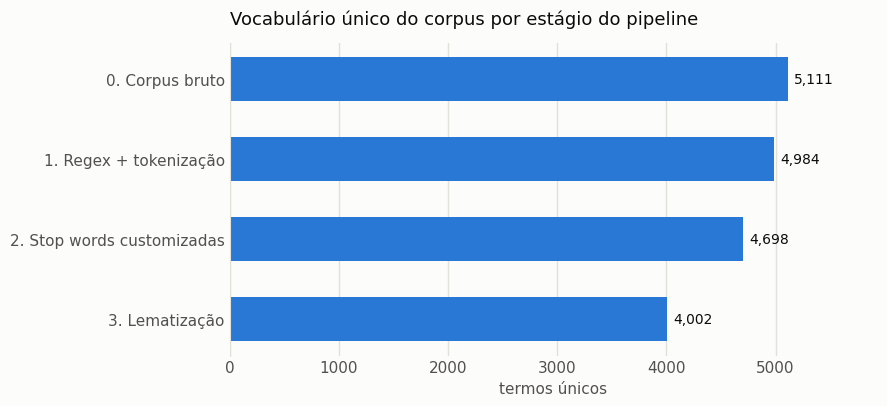

In [ ]:
# ---- Configuração visual comum aos gráficos ----
SUPERFICIE, TINTA, SECUNDARIA, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
AZUL = "#2a78d6"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "text.color": TINTA, "axes.labelcolor": SECUNDARIA,
    "xtick.color": SECUNDARIA, "ytick.color": SECUNDARIA,
    "font.family": "DejaVu Sans", "font.size": 11,
})

fig, ax = plt.subplots(figsize=(9, 4.2))
etiquetas = estagios["etapa"].tolist()[::-1]
valores = estagios["vocabulario"].tolist()[::-1]

barras = ax.barh(etiquetas, valores, color=AZUL, height=0.55)
for barra, valor in zip(barras, valores):
    ax.text(barra.get_width() + base_vocabulario * 0.012,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:,.0f}", va="center", ha="left", color=TINTA, fontsize=10)

ax.set_title("Vocabulário único do corpus por estágio do pipeline",
             color=TINTA, fontsize=13, pad=14, loc="left")
ax.set_xlabel("termos únicos")
ax.set_xlim(0, base_vocabulario * 1.16)
ax.xaxis.grid(True, color=GRADE, linewidth=1)
ax.set_axisbelow(True)
for lado in ("top", "right", "bottom"):
    ax.spines[lado].set_visible(False)
ax.spines["left"].set_color(GRADE)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

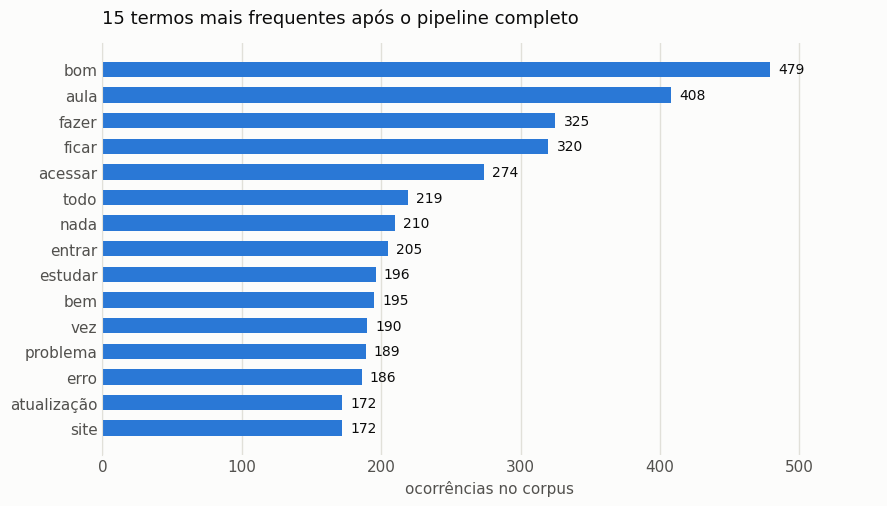

Leitura: os termos remanescentes descrevem o PROBLEMA relatado, não o
contexto compartilhado — que foi absorvido pelo dicionário de stop words.


In [ ]:
frequencia_final = Counter(t for tokens in apos_normalizacao for t in tokens)
principais = frequencia_final.most_common(15)[::-1]

fig, ax = plt.subplots(figsize=(9, 5.2))
termos = [t for t, _ in principais]
contagens = [c for _, c in principais]

barras = ax.barh(termos, contagens, color=AZUL, height=0.6)
for barra, valor in zip(barras, contagens):
    ax.text(barra.get_width() + max(contagens) * 0.012,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:,}", va="center", ha="left", color=TINTA, fontsize=10)

ax.set_title("15 termos mais frequentes após o pipeline completo",
             color=TINTA, fontsize=13, pad=14, loc="left")
ax.set_xlabel("ocorrências no corpus")
ax.set_xlim(0, max(contagens) * 1.16)
ax.xaxis.grid(True, color=GRADE, linewidth=1)
ax.set_axisbelow(True)
for lado in ("top", "right", "bottom"):
    ax.spines[lado].set_visible(False)
ax.spines["left"].set_color(GRADE)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

print("Leitura: os termos remanescentes descrevem o PROBLEMA relatado, não o")
print("contexto compartilhado — que foi absorvido pelo dicionário de stop words.")

In [ ]:
# Amostra qualitativa: texto original x saída do pipeline
for linha in df.query("nota <= 2").head(3).itertuples():
    print("=" * 100)
    print(f"[{linha.instituicao} | nota {linha.nota}]")
    print(f"ORIGINAL : {linha.texto[:280]}")
    print(f"PIPELINE : {' '.join(linha.tokens_processados)}")
print("=" * 100)

[Estácio | nota 1]
ORIGINAL : App abre e fica com a tela toda branca, uma dificuldade para entrar nas matérias, voltem atrás com a atualização
PIPELINE : abrir ficar tela todo branco dificuldade entrar matéria voltar atrás atualização
[Estácio | nota 1]
ORIGINAL : Achei horrível, tem hora que se você clica em algo e o app decidir que não quer abrir, você vai ter que esperar a boa vontade do app querer abrir naquela aba desejada que você está precisando. Pra um aplicativo que a faculdade é exatamente por lá. É péssimo. deveria ser muito bom
PIPELINE : achei horrível hora clico algo decidir nao_querer abrir ter esperar boa vontade querer abrir em aquele aba desejar precisar exatamente péssimo dever bom nao_dor cabeça bug
[Estácio | nota 1]
ORIGINAL : Atualizaram a UI quando você entra pra estudar uma matéria e ficou horrível, ficou mais difícil de navegar e estudar, mesma coisa com a versão web, não entendo o motivo de dificultar a vida já difícil do estudante...
PIPELINE : atualizaram e